## 使用@tool装饰器来调用工具

### 调用工具示例代码

In [1]:
from langchain.messages import HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from rich import print as rprint
from langchain_core.tools import tool

## 定义工具，需要使用@tool装饰器，同时作为工具的函数需要有docstring
@tool
def get_weather(city: str="北京"):
    """ 
    查询指定城市天气信息

    Args:
        city : 具体的城市，如:北京等等

    Returns:
        返回城市的天气     
    """

    return f"{city}天气晴朗，万里无云"
    
model = ChatOpenAI(
    model="qwen3-vl:latest",
    api_key="sk1234567",
    base_url="http://localhost:11434/v1"
)

tmodel = model.bind_tools([get_weather])
msgs = [
    HumanMessage("北京的天气怎么样？"),
]

resp = model.invoke(msgs)
tool_calls = resp.tool_calls

for tool_call in tool_calls:
    if tool_call["name"] == "get_weather":
        tresp = ToolMessage(
            content=get_weather.invoke(**tool_call["args"]),
            tool_call_id=tool_call["id"],
            name=tool_call["name"]
        )

        msgs.append(tresp)
print("========================messages===============================")
for msg in msgs:
    msg.pretty_print()
print("========================messages===============================")
res = tmodel.invoke(msgs)
rprint(res)

========================messages===============================
================================ Human Message =================================

北京的天气怎么样？
========================messages===============================


AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 137,
            'prompt_tokens': 172,
            'total_tokens': 309,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1}
        },
        'model_provider': 'openai',
        'model_name': 'qwen3-vl:latest',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-120',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--01a0c6d1-519e-79d1-b9c4-f57ba8f79d31-0',
    tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_fbl3t2xc', 'type': 'tool_call'}],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 172,
        'output_tokens': 137,
        'total_tokens': 309,
        'input_token_details': {'cache_read': 1},
        'output_token_details': {}
    }
)

## 使用Pydantic模型定义
### 1.pydantic类型的定义

### 没有Field，检测不到默认值

In [ ]:
from pydantic import BaseModel
from langchain_core.tools import tool

#定义一个类继承之BaseModel
class WeatherInput(BaseModel):
    city:str

## 定义工具，需要使用@tool装饰器，同时作为工具的函数需要有docstring
@tool(args_schema=WeatherInput)
def get_weather(city="北京"): #因为我们在args_schema对应的类已经定义了city的数据类型，所以这里可以不写类型
    """ 查询指定城市天气信息"""

    return f"{city}天气晴朗，万里无云"
from rich import print as rprint
from langchain_core.utils.function_calling import convert_to_openai_tool

rprint(convert_to_openai_tool(get_weather))


{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '查询指定城市天气信息',
        'parameters': {'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}
    }
}

### 使用Field，可以检测到默认值

In [4]:
from pydantic import BaseModel,Field
from langchain_core.tools import tool

#定义一个类继承之BaseModel
class WeatherInput(BaseModel):
    city:str = Field(
        description="具体的城市",
        default="北京"
    )

## 定义工具，需要使用@tool装饰器，同时作为工具的函数需要有docstring
@tool(args_schema=WeatherInput)
def get_weather(city): #因为我们在args_schema对应的类已经定义了city的数据类型，所以这里可以不写类型
    """ 查询指定城市天气信息"""

    return f"{city}天气晴朗，万里无云"

from rich import print as rprint
from langchain_core.utils.function_calling import convert_to_openai_tool

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '查询指定城市天气信息',
        'parameters': {
            'properties': {'city': {'default': '北京', 'description': '具体的城市', 'type': 'string'}},
            'type': 'object'
        }
    }
}

### 从的一有限的一些选项在选择一个
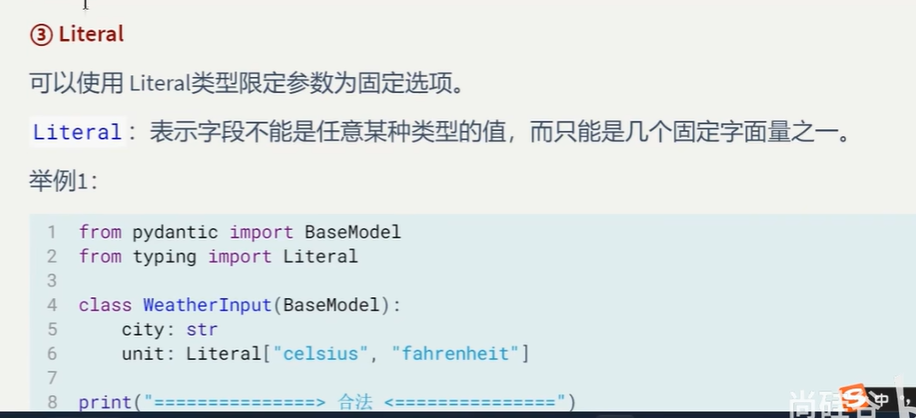

In [6]:
from typing import Literal

from pydantic import BaseModel,Field
from langchain_core.tools import tool

#定义一个类继承之BaseModel
class WeatherInput(BaseModel):
    city:str = Field(
        description="具体的城市",
        default="北京"
    )
    unit:Literal["celsius","fahrenheit"]

## 定义工具，需要使用@tool装饰器，同时作为工具的函数需要有docstring
@tool(args_schema=WeatherInput)
def get_weather(city,unit): #因为我们在args_schema对应的类已经定义了city的数据类型，所以这里可以不写类型
    """ 查询指定城市天气信息"""

    return f"{city}天气晴朗，万里无云,气温30{unit}"

from rich import print as rprint
from langchain_core.utils.function_calling import convert_to_openai_tool

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '查询指定城市天气信息',
        'parameters': {
            'properties': {
                'city': {'default': '北京', 'description': '具体的城市', 'type': 'string'},
                'unit': {'enum': ['celsius', 'fahrenheit'], 'type': 'string'}
            },
            'required': ['unit'],
            'type': 'object'
        }
    }
}

## 使用Json schema

In [7]:
from typing import Literal

from pydantic import BaseModel,Field
from langchain_core.tools import tool

param_dict={
            'properties': {
                'city': {'default': '北京', 'description': '具体的城市', 'type': 'string'},
                'unit': {'enum': ['celsius', 'fahrenheit'], 'type': 'string'},
                'include_forecast':{
                    'default':False,
                    'description':'是否包含未来五天的天气预报',
                    'type': 'boolean'
                }
            },
            'required': ['unit','include_forecast'],
            'type': 'object'
        }

## 定义工具，需要使用@tool装饰器，同时作为工具的函数需要有docstring
@tool(args_schema=param_dict)
def get_weather(city,unit): #因为我们在args_schema对应的类已经定义了city的数据类型，所以这里可以不写类型
    """ 查询指定城市天气信息"""

    return f"{city}天气晴朗，万里无云,气温30{unit}"

from rich import print as rprint
from langchain_core.utils.function_calling import convert_to_openai_tool

rprint(convert_to_openai_tool(get_weather))

{
    'type': 'function',
    'function': {
        'name': 'get_weather',
        'description': '查询指定城市天气信息',
        'parameters': {
            'properties': {
                'city': {'default': '北京', 'description': '具体的城市', 'type': 'string'},
                'unit': {'enum': ['celsius', 'fahrenheit'], 'type': 'string'},
                'include_forecast': {
                    'default': False,
                    'description': '是否包含未来五天的天气预报',
                    'type': 'boolean'
                }
            },
            'required': ['unit', 'include_forecast'],
            'type': 'object'
        }
    }
}